# `Reporting Excel automatisé en Python`
*Oscar JOSEPH--GENESLAY*
**Data :** SuperStore Dataset
Source : *[Kaggle - SuperStore Dataset par vivek468](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final?resource=download)*

# Importation des packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime
import openpyxl
from openpyxl.chart import BarChart, Reference, DoughnutChart, series
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.worksheet.formula import ArrayFormula
from openpyxl.utils import FORMULAE
from openpyxl.utils.cell import coordinate_from_string
from openpyxl.chart.series import DataPoint
from openpyxl.chart.label import DataLabelList
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.worksheet.datavalidation import DataValidation
from pathlib import Path
import pandas as pd
import os
import boto3

# Importation des données

In [3]:
dataset = pd.read_csv(
    "https://minio.lab.sspcloud.fr/oscar04/Superstore/Superstore.csv",
    encoding="windows-1252"
)

dataset.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

# Reformatage des colonnes

In [5]:
# Retypage
dataset["Row ID"] = str(dataset["Row ID"])
dataset["Postal Code"] = str(dataset["Postal Code"])


# Transformation en format date
dataset["Order Date"] = pd.to_datetime(dataset["Order Date"], format='%d/%m/%Y', errors='coerce')
dataset["Ship Date"] = pd.to_datetime(dataset["Ship Date"], format='%d/%m/%Y', errors='coerce')

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   str           
 1   Order ID       9994 non-null   str           
 2   Order Date     4042 non-null   datetime64[us]
 3   Ship Date      3898 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   str           
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

# Exploration de données

Étude des valeurs manquantes

In [15]:
nbr_na_par_colonne = (dataset.isna().sum() / len(dataset)) * 100

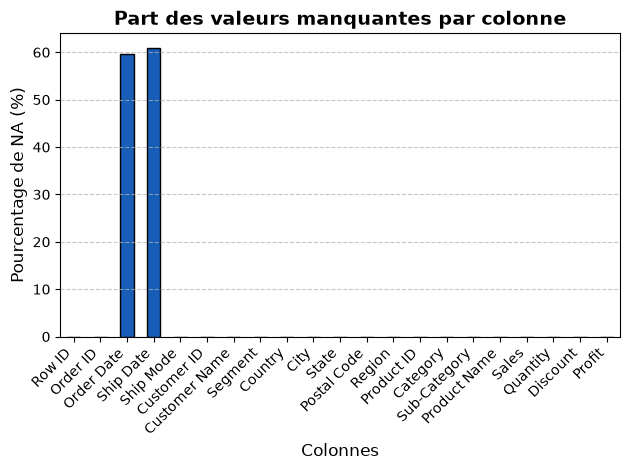

In [18]:
# Création du graphique
nbr_na_par_colonne.plot(kind='bar', color='#185EB8', edgecolor='black')

# Personnaliser le graphique
plt.title('Part des valeurs manquantes par colonne', fontsize=14, fontweight='bold')
plt.ylabel('Pourcentage de NA (%)', fontsize=12)
plt.xlabel('Colonnes', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Affichage
plt.show()

Chiffre d'affaires par sous catégorie

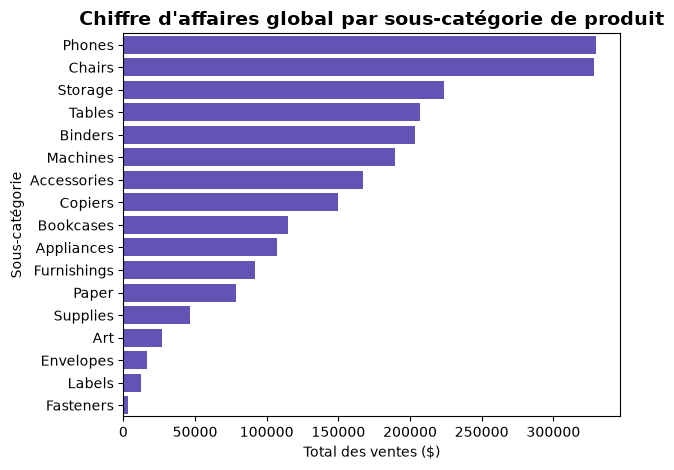

In [ ]:
# Trier les données par ventes
category_data = dataset.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()

# Graphique des ventes
sns.barplot(x='Sales', y='Sub-Category', data=category_data, color="#5943C4", legend=False)
plt.title("Chiffre d'affaires global par sous-catégorie de produit", fontsize=14, fontweight='bold')
plt.xlabel("Total des ventes ($)")
plt.ylabel("Sous-catégorie")
plt.tight_layout()
plt.show()

Les commandes en fonction de la région Est, Ouest, Centre, Sud

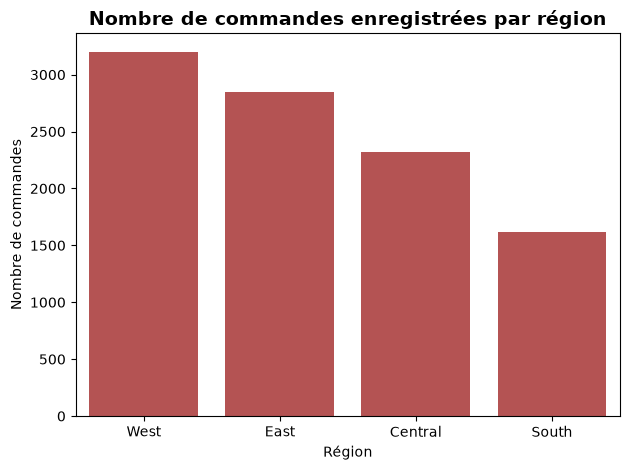

In [ ]:
sns.countplot(x='Region', data=dataset, color="#C44343", order=dataset['Region'].value_counts().index, legend=False)
plt.title("Nombre de commandes enregistrées par région", fontsize=14, fontweight='bold')
plt.xlabel("Région")
plt.ylabel("Nombre de commandes")
plt.tight_layout()
plt.show()

Montant du CA par État - Carte

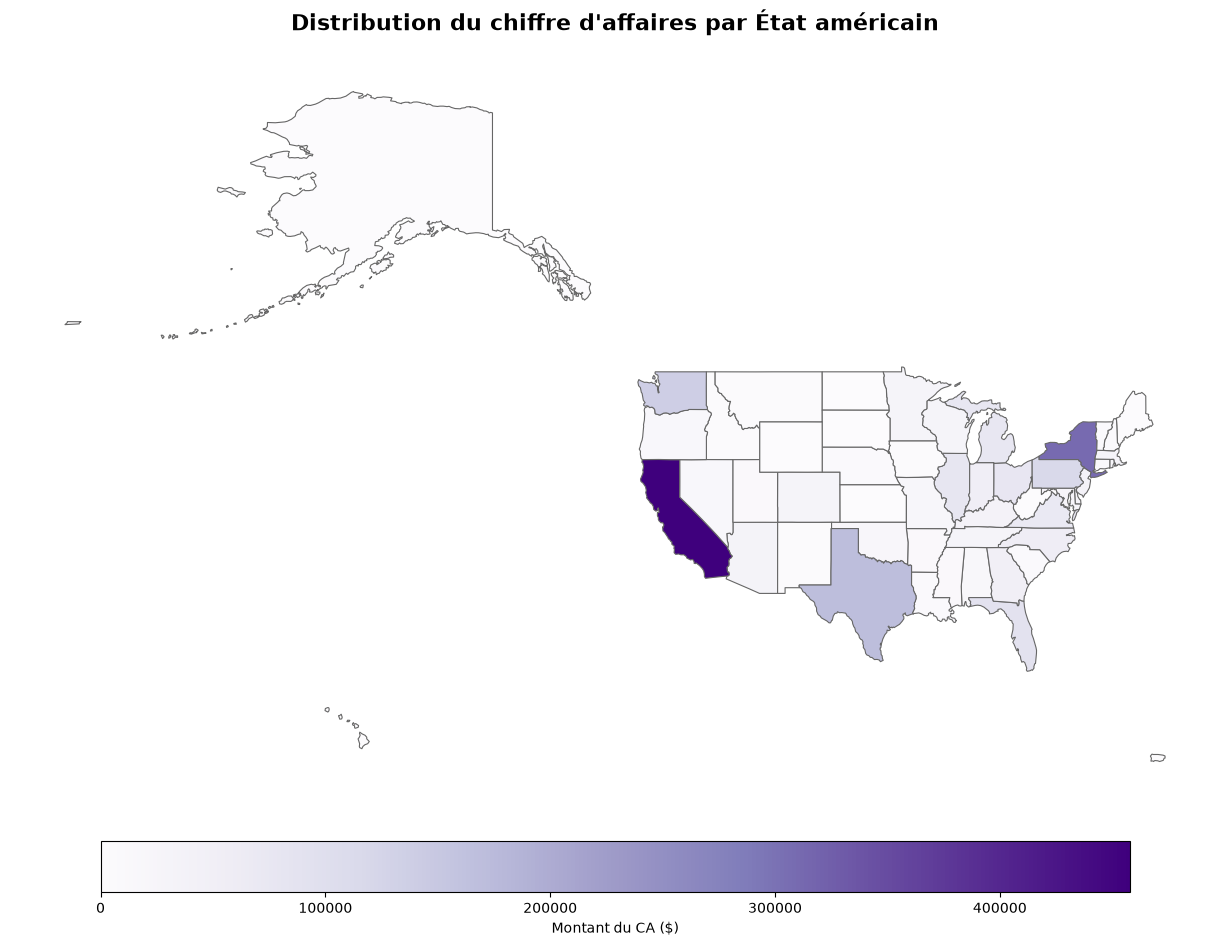

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Préparation des données
state_data = dataset.groupby('State').agg(
    Total_Ventes=('Sales', 'sum')
).reset_index()

# Charger le fond de carte des USA
usa_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
usa_map = gpd.read_file(usa_url)
usa_map = usa_map.rename(columns={'name': 'State'})

# Fusionner la carte et les ventes
merged = usa_map.merge(state_data, on='State', how='left')
merged['Total_Ventes'] = merged['Total_Ventes'].fillna(0) # Gestion des États sans ventes

# Tracer la carte du CA
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

merged.plot(column='Total_Ventes',cmap='Purples', linewidth=0.8,ax=ax,edgecolor='0.4',legend=True,legend_kwds={
    'label': "Montant du CA ($)",
    'orientation': "horizontal",
    'pad': 0.05,
    'shrink': 0.7})

# Titre et affichage
ax.set_title("Distribution du chiffre d'affaires par État américain", fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Fichier du reporting

## Création du fichier Excel

In [5]:
# Créer le chemin d'export
chemin_dossier = Path("../output")
chemin_dossier.mkdir(parents=True, exist_ok=True)

# On exporte le fichier de travail
path = "../output/reporting.xlsx"
with pd.ExcelWriter(path, engine="openpyxl") as writer:
    dataset.to_excel(writer, sheet_name="DATA", index=False)

print("✅ reporting.xlsx créé")

✅ reporting.xlsx créé


## Chargement du reporting en mémoire

In [6]:
# Charger le classeur (workbook) en mémoire
wb = openpyxl.load_workbook('../output/reporting.xlsx')

# Création d'une feuille visualisations
ws_visualisations = wb.create_sheet(title="VISUALISATIONS")
ws_visualisations.sheet_view.showGridLines = False

# Définir la feuille DATA en variable python
ws_data = wb["DATA"]

# wb est un objet Python — on ne peut pas afficher son contenu avec un simple print
print(type(wb))
print('Feuilles disponibles :', wb.sheetnames)

<class 'openpyxl.workbook.workbook.Workbook'>
Feuilles disponibles : ['DATA', 'VISUALISATIONS']


# Création des KPIs

### KPIs numériques

##### CA ; Profits ; Quantité

Ecrire la fonction Excel

In [7]:
def _add_numerical_formula(cell, colonne):
    cell.value = f"=SUMIFS(DATA!{colonne}:{colonne}, DATA!M:M, VISUALISATIONS!B5, DATA!K:K, VISUALISATIONS!B11)"

Définir un style à la cellule

In [8]:
def _apply_kpi_style(cell, cell_format):
    cell.number_format = cell_format
    cell.font = Font(name="Calibri", size=16, bold=True, color="1F497D")
    cell.alignment = Alignment(horizontal="left", vertical="center")

Appliquer une largeurs et une hauteurs des lignes et des colonnes

In [9]:
def _adjust_dimensions(ws, cell, cell_format):
    col_letter = cell.column_letter
    current_width = ws.column_dimensions[col_letter].width or 10
    needed_width = max(len(cell_format) + 5, 18)
    
    ws.column_dimensions[col_letter].width = max(current_width, needed_width)
    ws.row_dimensions[cell.row].height = 30

Création de la fonction orchestratrice pour appliquer les éléments du dessus 

In [10]:
def write_numerical_kpi(ws, cell_ref, colonne, cell_format):
    """
    Fonction orchestratrice pour créer les kpis numériques en configurant le placement de la cellule et son style.
    """
    cell = ws[cell_ref]
    
    # Application des fonctions
    _add_numerical_formula(cell, colonne)
    _apply_kpi_style(cell, cell_format)
    _adjust_dimensions(ws, cell, cell_format)

Création des indicateurs numériques

In [11]:
# CA
write_numerical_kpi(ws_visualisations, "C4", "R", "#,##0.0 $")

# Profit
write_numerical_kpi(ws_visualisations, "E4", "U", "#,##0.0 $")

# Quantité
write_numerical_kpi(ws_visualisations, "G4", "S", "#,##0")

##### Temps de livraison

La fonction de calcul de différence entre date existe dans openpyxl

In [12]:
"DATEDIF" in FORMULAE

True

Application de la formule datedif sur chaque ligne où c'est calculable

In [13]:
for row_cell in range(2, len(dataset)+2):
    cell_application = f"V{row_cell}"
    date_debut = f"C{row_cell}"
    date_fin = f"D{row_cell}"
    ws_data[cell_application] = f'=IF(OR({date_debut} = "", {date_fin} = ""), "", DATEDIF({date_debut}, {date_fin}, "D"))'

Création du KPI moyenne 

La fonction AVREAGEIF existe dans openpyxl

In [14]:
"AVERAGEIF" in FORMULAE

True

Calcul de la moyenne du temps de livraison

In [15]:
ws_visualisations["J4"] = "=ROUND(AVERAGEIFS(DATA!V:V, DATA!M:M, VISUALISATIONS!B5, DATA!K:K, VISUALISATIONS!B11),1)"

Définir le style de la cellule et son format

In [16]:
def apply_kpi_design(ws, cell_ref, cell_format):
    """
    Applique le style et ajuste les dimensions d'un KPI déjà créé
    """
    cell = ws[cell_ref]
    
    _apply_kpi_style(cell, cell_format)
    _adjust_dimensions(ws, cell, cell_format)

Application du style de cellule au temps de livraison

In [17]:
apply_kpi_design(ws_visualisations, "J4", "0.0")

### TOP10 des sous-catégories avec le plus de profits

1. Calcul des profits par sous catégories et création du top 10

La fonction UNIQUE n'existe pas dans openpyxl

In [18]:
"UNIQUE" in FORMULAE

False

Calcul du nombre de sous catégories

In [19]:
len_sous_cat = len(dataset["Sub-Category"].unique())+1
# Calcul du nombre de sous catégories
len_dict ={}
for col in ["Sub-Category"]:
    len_dict["len_sous_cat"] = len(dataset[col].unique())+1 # on rajoute +1 car python commence à 0
len_dict

{'len_sous_cat': 18}

Application de la formule UNIQUE

In [20]:
formula = "=_xlfn.UNIQUE(DATA!P:P)"
ws_data['Z2'] = ArrayFormula(f"Z2:Z{len_dict['len_sous_cat']+1}", formula)

Calculer le profits par sous catégories

In [21]:
for num_cell in range(3, len_dict['len_sous_cat']+2):
    cell = "AA" + str(num_cell)
    ws_data[cell] = "=SUMIFS(DATA!U:U,DATA!P:P,DATA!Z" + str(num_cell) + ",DATA!M:M,Visualisations!$B$5, DATA!K:K, VISUALISATIONS!$B$11)"

La fonction "SORT" n'existe pas dans openpyxl

In [22]:
"SORT" in FORMULAE

False

Application du tri du tableau de données

In [23]:
# Trier le tableau de données
formula = "=_xlfn.SORT(DATA!Z3:AA19,2,-1)"
ws_data['AC3'] = ArrayFormula("AC3:AD19", formula)

2. Création du graphique à barres

In [24]:
# Création du graphique à barres
chart_top10 = BarChart()
chart_top10.type = "col"
chart_top10.title = "TOP 10 du profit en fonction des sous-catégories"
chart_top10.width = 18
chart_top10.height = 10

# Récupération des données de profits
data_ref = Reference(ws_data, min_col=30, min_row=3, max_row=12)

# Récupération des labels
cats_ref = Reference(ws_data, min_col=29, min_row=4, max_row=12)

# Appliquer les paramètres au graphique
chart_top10.add_data(data_ref, titles_from_data=True)
chart_top10.set_categories(cats_ref)

# Ajouter les étiquettes de données
chart_top10.dataLabels = DataLabelList()
chart_top10.dataLabels.showVal = True
chart_top10.dataLabels.numFmt = '#,##0'

# Titres des axes
chart_top10.y_axis.title = 'Profits (en $)'
chart_top10.x_axis.title = 'Sous-catégories'

# Légende
chart_top10.legend = None

# Placement du graphique
ws_visualisations.add_chart(chart_top10, "C7")

### Pourcentage de CA par catégories

Écrire les valeurs uniques des catégories disponibles

In [25]:
len_cat = len(dataset["Category"].unique())+1
# Calcul du nombre de sous catégories
len_dict ={}
for col in ["Category"]:
    len_dict["len_cat"] = len(dataset[col].unique())+1 # on rajoute +1 car python commence à 0
formula = "=_xlfn.UNIQUE(DATA!O:O)"
ws_data['Z25'] = ArrayFormula(f"Z25:Z{len_dict['len_cat']+24}", formula)

Calculer le CA pour chaque catégorie

In [26]:
for row_cell in range(26, 29):
    ws_data[f"AA{row_cell}"] = f"=SUMIFS(DATA!R:R, DATA!O:O, DATA!Z{row_cell}, DATA!M:M, Visualisations!$B$5, DATA!K:K, VISUALISATIONS!$B$11)"

Calculer le pourcentage du CA par catégorie

In [27]:
ws_data["AA29"] = "=SUM(AA26:AA28)"
for row_cell in range(26, 29):
    ws_data[f"AB{row_cell}"] = f"=AA{row_cell} / AA29"
    ws_data[f"AB{row_cell}"].number_format = '0.00%'

Génération du graphique

In [28]:
chart_percent = DoughnutChart()
chart_percent.width = 18
chart_percent.height = 10
labels = Reference(ws_data, min_col=26, min_row=26, max_row=28)
data = Reference(ws_data, min_col=28, min_row=25, max_row=28)
chart_percent.add_data(data, titles_from_data=True)
chart_percent.set_categories(labels)
chart_percent.title = "Part du CA pour chaque catégorie"

chart_percent.dataLabels = DataLabelList()
chart_percent.dataLabels.showPercent = True   # Afficher les pourcentages

# Cut the first slice out of the doughnut
slices = [DataPoint(idx=i) for i in range(4)]
plain, jam, lime, chocolate = slices
chart_percent.series[0].data_points = slices
plain.graphicalProperties.solidFill = "A9E6EB"
jam.graphicalProperties.solidFill = "B7A9EB"
lime.graphicalProperties.solidFill = "EBA9D7"

ws_visualisations.add_chart(chart_percent, "C27")


### La méthode ABC

Récupération des valeurs uniques des noms de produits

In [29]:
len_products = len(dataset["Product Name"].unique())+1
# Calcul du nombre de produits
len_dict ={}
for col in ["Product Name"]:
    len_dict["len_products"] = len(dataset[col].unique())+1 # on rajoute +1 car python commence à 0
len_dict

formula = "=_xlfn.UNIQUE(DATA!Q:Q)"
ws_data['Z33'] = ArrayFormula(f"Z33:Z{len_dict['len_products']+1}", formula)

Calcul du CA par produit

In [30]:
for num_cell in range(34, len_dict['len_products']+36):
    cell = "Y" + str(num_cell)
    ws_data[cell] = "=SUMIFS(DATA!R:R,DATA!Q:Q,DATA!Z" + str(num_cell) + ",DATA!M:M,Visualisations!$B$5, DATA!K:K, VISUALISATIONS!$B$11)"
# Calcul du total de CA
ws_data["Y33"] = f"=SUM(DATA!Y34:Y{len_dict['len_products']+1})"

Calcul part du CA du produit sur le Ca total

In [31]:
for num_cell in range(34, len_dict['len_products']+36):
    ws_data[f"X{num_cell}"] = f"=Y{num_cell}/$Y$33"

Tri dans l'ordre décroissant en fonction du niveau de la part

In [32]:
# Trier le tableau de données
formula = f"=_xlfn.SORT(DATA!X34:Z{len_dict['len_products']+36},1,-1)"
ws_data[f'Y{len_dict['len_products']+40}'] = ArrayFormula(f"Y{len_dict['len_products']+40}:AA{len_dict['len_products']*2+37}", formula)

Calcul de la part cumulée et classification en A, B ou C du produit

In [33]:
start_cell = len_dict['len_products'] + 40
end_cell = len_dict['len_products'] * 2 + 40

# Gérer le premier cas
ws_data[f"X{start_cell}"] = f"=Y{start_cell}"
ws_data[f"W{start_cell}"] = f'=IF(X{start_cell} <= 0.8, "A", IF(X{start_cell} <= 0.95, "B", "C"))'

# Boucle pour le reste des cellules
for num_cell in range(start_cell + 1, end_cell + 1):
    # Cumul
    ws_data[f"X{num_cell}"] = f"=Y{num_cell} + X{num_cell-1}"
    
    # Classification ABC
    ws_data[f"W{num_cell}"] = f'=IF(X{num_cell} <= 0.8, "A", IF(X{num_cell} <= 0.95, "B", "C"))'

Insère la formule pour une catégorie

In [34]:
def _write_category_formula(ws, cell_ref, category, start_row, end_row, row_fin):
    col_letter, start_row_idx = coordinate_from_string(cell_ref)
    formula = f'=_xlfn.FILTER(DATA!AA{start_row}:AA{end_row}, DATA!W{start_row}:W{end_row}="{category}", "Aucun")'
    
    # On applique la formule sur la bonne colonne calculée
    ws[cell_ref] = ArrayFormula(f"{cell_ref}:{col_letter}{row_fin}", formula)

Adapte la taille de la cellule

In [35]:
def _adjust_category_dimension(ws, cell_ref):
    col_letter, _ = coordinate_from_string(cell_ref)
    ws.column_dimensions[col_letter].width = 45

Définir un style 

In [36]:
def _apply_category_alignment(ws, cell_ref, row_fin):
    col_letter, start_row_idx = coordinate_from_string(cell_ref)
    alignement_propre = Alignment(wrap_text=True, vertical='top')
    
    for row in range(start_row_idx, row_fin + 1):
        ws[f"{col_letter}{row}"].alignment = alignement_propre

Fonction orchestratrice pour créer la liste des produits par category

In [37]:
def write_category(ws, cell_ref, category, start_row, end_row, len_products):
    """
    Orchestre l'insertion et la mise en forme d'une seule liste filtrée (A, B ou C)
    """
    row_fin = 7 + len_products 
    
    _write_category_formula(ws, cell_ref, category, start_row, end_row, row_fin)
    _adjust_category_dimension(ws, cell_ref)
    _apply_category_alignment(ws, cell_ref, row_fin)

Application de la fonction orchestratrice pour créer la liste des produits de chaque catégorie

In [38]:
# A
write_category(ws_visualisations, "K7", "A", start_cell, end_cell, len_dict['len_products'])

# B
write_category(ws_visualisations, "N7", "B", start_cell, end_cell, len_dict['len_products'])

# C
write_category(ws_visualisations, "P7", "C", start_cell, end_cell, len_dict['len_products'])

# Ajout du filtre

Création d'une fonction pour automatiser la mise en place d'un filtre. Lors de l'ajout d'un filtre, il faut également modifier les fonctions SUMIFS et AVERAGEIFS pour ajouter la référence de la cellule en condition.

In [ ]:
def create_filter(column_ref, title, cell_ref_title, cell_ref_filter) :
    # Récupérer les valeurs uniques de la colonne à filtrer
    distinct_value_list = ",".join(dataset[column_ref].unique())
    ws_visualisations[cell_ref_title] = title
    ws_visualisations[cell_ref_filter] = dataset[column_ref][0]  # Valeur par défaut

    # liste de valeurs du filtre
    dv = DataValidation(
        type="list", formula1=f'"{distinct_value_list}"', allow_blank=True
    )

    # Ajout du filtre dans la feuille
    ws_visualisations.add_data_validation(dv)
    dv.add(ws_visualisations[cell_ref_filter])

Création des filtres

In [ ]:
# Région
create_filter("Region", "Choisir une région :", "A5", "B5")

# États
create_filter("State", "Choisir un État :", "A11", "B11")

# Création de l'aspect design

### Le titre

In [39]:
ws_visualisations["K1"] = "Performances économique"
ws_visualisations["K1"].font = Font(bold=True, size=28, color="185EB8")

### Design KPIs numériques

Définir un titre

In [40]:
def _add_title_value(cell, titre):
    cell.value = titre

Définir le style d'un titre

In [41]:
def _apply_title_style(cell):
    cell.font = Font(bold=True, size=16)

Fonction pour créer les titres des indicateurs

In [42]:
def write_kpi_title(ws, cell_ref, titre):
    """
    Orchestre l'insertion et la mise en forme du titre d'un KPI
    """
    cell = ws[cell_ref]
    
    _add_title_value(cell, titre)
    _apply_title_style(cell)

Création des titres pour les indicateurs numériques

In [43]:
# CA
write_kpi_title(ws_visualisations, "C3", "Chiffre d'affaires")

# Profits
write_kpi_title(ws_visualisations, "E3", "Profits")

# Quantités
write_kpi_title(ws_visualisations, "G3", "Volume des ventes")

# Temps livraison
write_kpi_title(ws_visualisations, "J3", "Temps de livraison moyen (en jours)")

### Design Méthode ABC

Insérer la lettre (A, B ou C)

In [44]:
def _add_abc_value(cell, letter):
    cell.value = letter

Appliquer un style à la cellule

In [45]:
def _apply_abc_style(cell, color):
    cell.font = Font(bold=True, size=14)
    cell.fill = PatternFill(start_color=color, fill_type="solid")
    cell.alignment = Alignment(horizontal="center", vertical="center")

Fonction orchestratrice pour créer les en-têtes des colonnes de la méthode ABC

In [46]:
def write_abc_title(ws, cell_ref, letter, color):
    """
    Orchestre l'insertion et le design des en-têtes de colonnes pour la méthode ABC
    """
    cell = ws[cell_ref]
    
    _add_abc_value(cell, letter)
    _apply_abc_style(cell, color)

Création des en tête de colonnes

In [47]:
write_abc_title(ws_visualisations, "K6", "A", "56E871") # Catégorie A
write_abc_title(ws_visualisations, "N6", "B", "E8DC56") # Catégorie B
write_abc_title(ws_visualisations, "P6", "C", "E87B56") # Catégorie C

### Design de la partie filtre

Configurer la structure du filtre

In [48]:
def _setup_filter_structure(ws):
    ws.column_dimensions['A'].width = 16.5
    ws.column_dimensions['B'].width = 17.56
    ws.merge_cells('A4:B4')

Insertion et style du texte 

In [49]:
def _write_filter_title(ws):
    ws['A4'] = "Filtres"
    ws['A4'].font = Font(bold=True, size=15)
    ws['A4'].alignment = Alignment(horizontal="center", vertical="center")

Définit le style du filtre

In [50]:
def _apply_filter_design(ws):
    fond_gris = PatternFill(start_color="F2F2F2", fill_type="solid")
    bordure_fine = Border(
        left=Side(border_style="thin", color="A6A6A6"),
        right=Side(border_style="thin", color="A6A6A6"),
        top=Side(border_style="thin", color="A6A6A6"),
        bottom=Side(border_style="thin", color="A6A6A6"))
    # Application du fond
    for num_cell in range(4, 24):
        ws[f'A{num_cell}'].fill = fond_gris
        ws[f'B{num_cell}'].fill = fond_gris

    # Application de la bordure du titre
    ws['A4'].border = bordure_fine
    ws['B4'].border = bordure_fine

Fonction orchestratrice pour le design des filtres

In [51]:
def create_filter_panel(ws):
    """
    Orchestre la création et le design visuel du panneau de filtres.
    """
    _setup_filter_structure(ws)
    _write_filter_title(ws)
    _apply_filter_design(ws)

In [52]:
# Construction du panneau latéral gauche
create_filter_panel(ws_visualisations)

# Export du reporting

Sauvegarde du fichier

In [55]:
chemin_local = "../output/reporting.xlsx"
wb.save(chemin_local)

Export sur Minio

In [56]:
# Récupération de l'URL de MinIO
s3_endpoint = os.environ.get("AWS_S3_ENDPOINT")

# Initialisation de la connexion S3
s3 = boto3.client("s3", endpoint_url=f"https://{s3_endpoint}")

# Définition des chemins
nom_du_bucket = "oscar04" 
chemin_minio = "Superstore/reporting.xlsx" # Le dossier et le nom du fichier sur ton espace cloud

# Envoi du fichier
s3.upload_file(chemin_local, nom_du_bucket, chemin_minio)

print(f"✅ Fichier exporté avec succès sur MinIO dans le bucket {nom_du_bucket}/{chemin_minio}")

✅ Fichier exporté avec succès sur MinIO dans le bucket oscar04/Superstore/reporting.xlsx
